# BCI Final Project: Motor Imagery Classification with Braindecode

**Dataset**: BCI Competition III Dataset IVa  
**Task**: Right hand vs Right foot motor imagery classification  
**Models**: EEGNet, ShallowFBCSPNet, Deep4Net, TCN (+ EEGConformer if compatible)  
**Bonus**: Data Augmentation + Advanced Models

In [1]:
!pip install braindecode mne

     ---------------------------------------- 0.0/77.6 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/77.6 kB ? eta -:--:--
     --------------- ---------------------- 30.7/77.6 kB 435.7 kB/s eta 0:00:01
     -------------------- ----------------- 41.0/77.6 kB 330.3 kB/s eta 0:00:01
     ------------------------------ ------- 61.4/77.6 kB 365.7 kB/s eta 0:00:01
     -------------------------------------- 77.6/77.6 kB 391.6 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of hyper-connections to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of hyper-connections to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this 

## 1. Setup and Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

import mne
from mne.preprocessing import ICA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from braindecode.models import EEGNetv4, ShallowFBCSPNet, Deep4Net, EEGConformer, TCN
from braindecode.util import set_random_seeds

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
set_random_seeds(seed=42, cuda=torch.cuda.is_available())

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"MNE version: {mne.__version__}")

Using device: CPU
PyTorch version: 2.2.2+cpu
MNE version: 1.10.2


## 2. Configuration

In [3]:
SUBJECTS = ["aa", "al", "av", "aw", "ay"]
DATA_FILES = {s: f"/kaggle/input/bci-competition-iii-dataset-iv/data_set_IVa_{s}.mat" for s in SUBJECTS}

FS_EXPECTED = 100.0
SCALE_TO_VOLTS = 0.1e-6
EVENT_ID = {"right": 1, "foot": 2}

FILTER_LOW = 1.0
FILTER_HIGH = 40.0

EPOCH_TMIN = 0.0
EPOCH_TMAX = 4.0

ICA_N_COMPONENTS = 15
EOG_CANDIDATES = ["FP1", "FP2", "FPZ", "AFZ", "AF7", "AF8", "F7", "F8"]

BATCH_SIZE = 32
EPOCHS = 400
LEARNING_RATE = 0.001

## 3. Data Loading

In [4]:
def load_iva_subject(mat_path: str):
    m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    
    cnt = m["cnt"].astype(np.float64) * SCALE_TO_VOLTS
    nfo = m["nfo"]
    fs = float(np.ravel(nfo.fs)[0])
    ch_names = [str(c) for c in np.ravel(nfo.clab)]
    
    info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types="eeg")
    raw = mne.io.RawArray(cnt.T, info, verbose=False)
    
    mrk = m["mrk"]
    pos = np.ravel(mrk.pos).astype(int)
    y = np.ravel(mrk.y)
    
    xpos = np.ravel(nfo.xpos).astype(float)
    ypos = np.ravel(nfo.ypos).astype(float)
    ch_pos = {name: (float(x), float(y), 0.0) for name, x, y in zip(ch_names, xpos, ypos)}
    mont = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame="head")
    
    return raw, pos, y, ch_names, fs, mont

print("Loading BCI Competition III Dataset IVa...")
raws_by_subject = {}
markers_by_subject = {}
montages_by_subject = {}

for s, f in DATA_FILES.items():
    assert Path(f).exists(), f"Missing file: {f}"
    raw, pos, y, ch_names, fs, mont = load_iva_subject(f)
    
    if FS_EXPECTED and abs(fs - FS_EXPECTED) > 1e-6:
        raw.resample(FS_EXPECTED, npad="auto")
        fs = raw.info["sfreq"]
    
    raws_by_subject[s] = raw
    markers_by_subject[s] = {"pos": pos, "y": y}
    montages_by_subject[s] = mont
    
    print(f"  {s}: {raw.times[-1]:.1f}s, {fs:.1f} Hz, {len(ch_names)} channels")

print(f"\nLoaded {len(raws_by_subject)} subjects")

Loading BCI Competition III Dataset IVa...


AssertionError: Missing file: /kaggle/input/bci-competition-iii-dataset-iv/data_set_IVa_aa.mat

## 4. Preprocessing

### 4.1 Channel Standardization

In [ ]:
for s, raw in raws_by_subject.items():
    raw.rename_channels(lambda x: x.strip().upper())
    mont = montages_by_subject[s]
    raw.set_montage(mont, on_missing="ignore", verbose=False)
    print(f"{s}: {len(raw.ch_names)} channels")

aa: 118 channels
al: 118 channels
av: 118 channels
aw: 118 channels
ay: 118 channels


In [ ]:
channels_to_plot = ["C3", "CZ", "C4", "FP1", "FP2"]
start_time, duration = 10, 10

for s, raw in raws_by_subject.items():
    present = [ch for ch in channels_to_plot if ch in raw.ch_names]
    if not present:
        present = raw.ch_names[:5]

    sfreq = raw.info["sfreq"]
    start_samp = int(start_time * sfreq)
    stop_samp  = int((start_time + duration) * sfreq)

    data, times = raw.get_data(
        picks=present,
        start=start_samp,
        stop=stop_samp,
        return_times=True
    )

    fig, ax = plt.subplots(1, 1, figsize=(15, 4))

    for i, ch in enumerate(present):
        ax.plot(times, data[i] * 1e6 + i * 50, label=ch)

    ax.set_title(f"{s.upper()} — Raw EEG (Unfiltered)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Raw EEG visualization complete for subject {s}.")

### 4.2 Bandpass Filtering (1-40 Hz)

In [53]:
filtered_by_subject = {}

for s, raw in raws_by_subject.items():
    rf = raw.copy().filter(l_freq=FILTER_LOW, h_freq=FILTER_HIGH, fir_design="firwin", verbose=False)
    filtered_by_subject[s] = rf
    print(f"{s}: filtered {FILTER_LOW}-{FILTER_HIGH} Hz")

print("\nFiltering complete")

aa: filtered 1.0-40.0 Hz
al: filtered 1.0-40.0 Hz
av: filtered 1.0-40.0 Hz
aw: filtered 1.0-40.0 Hz
ay: filtered 1.0-40.0 Hz

Filtering complete


### 4.3 ICA Artifact Removal

In [54]:
raw_clean_by_subject = {}

for s, raw_filt in filtered_by_subject.items():
    raw_ref = raw_filt.copy().set_eeg_reference("average", verbose=False)
    
    ica = ICA(n_components=ICA_N_COMPONENTS, random_state=42, max_iter=800, method="fastica")
    ica.fit(raw_ref, verbose=False)
    
    present = [c for c in EOG_CANDIDATES if c in raw_filt.ch_names]
    eog_idx = []
    if len(present) > 0:
        eog_idx, _ = ica.find_bads_eog(raw_filt, ch_name=present, threshold=2.5, verbose=False)
    
    ica.exclude = list(eog_idx)
    raw_clean = raw_filt.copy()
    ica.apply(raw_clean, verbose=False)
    
    raw_clean_by_subject[s] = raw_clean
    print(f"{s}: ICA excluded {len(eog_idx)} components")

print("\nICA complete")

aa: ICA excluded 3 components
al: ICA excluded 2 components
av: ICA excluded 2 components
aw: ICA excluded 3 components
ay: ICA excluded 3 components

ICA complete


### 4.3.1 Visualization: Before vs After ICA

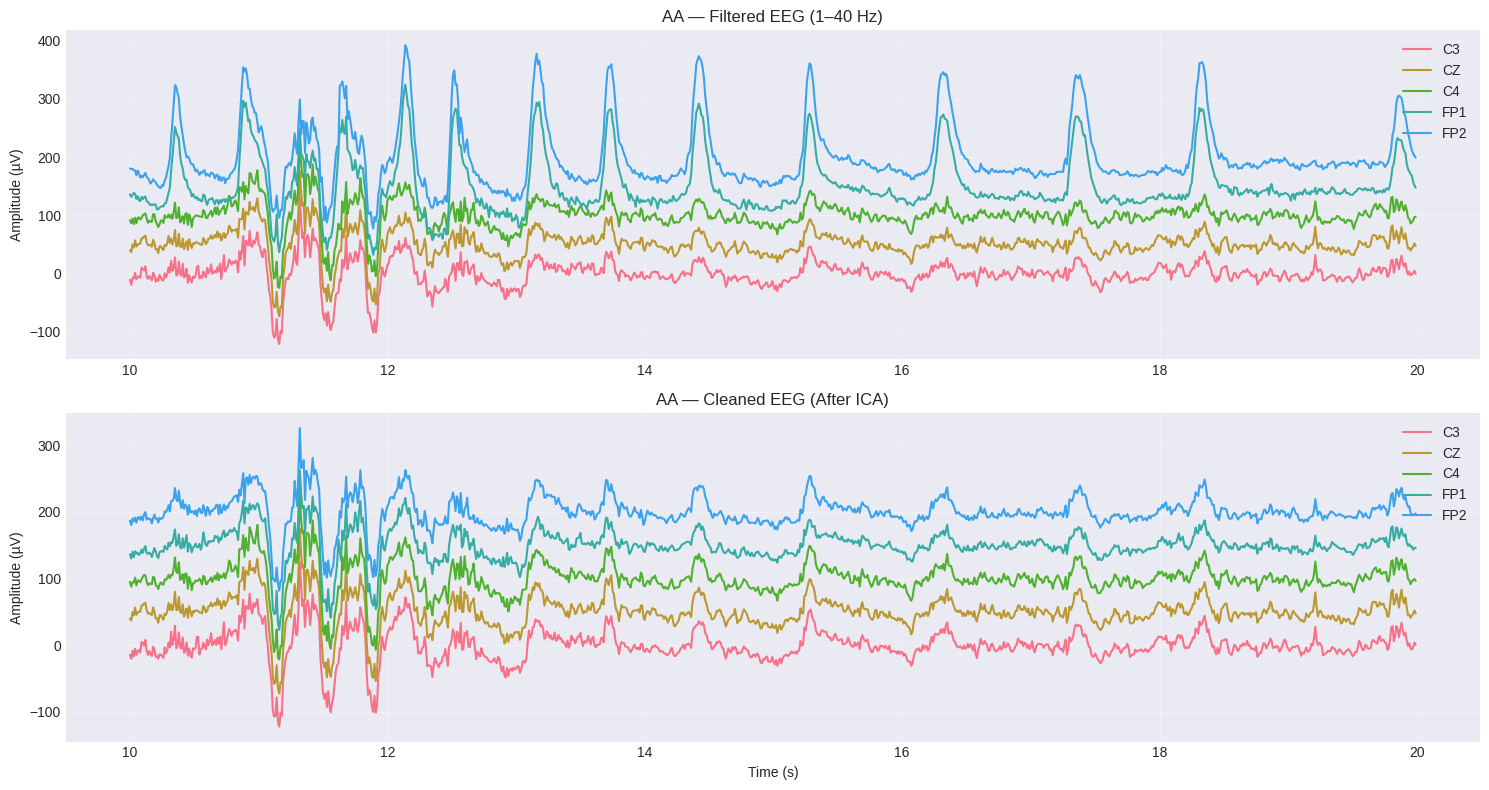

EEG visualization complete for subject aa.


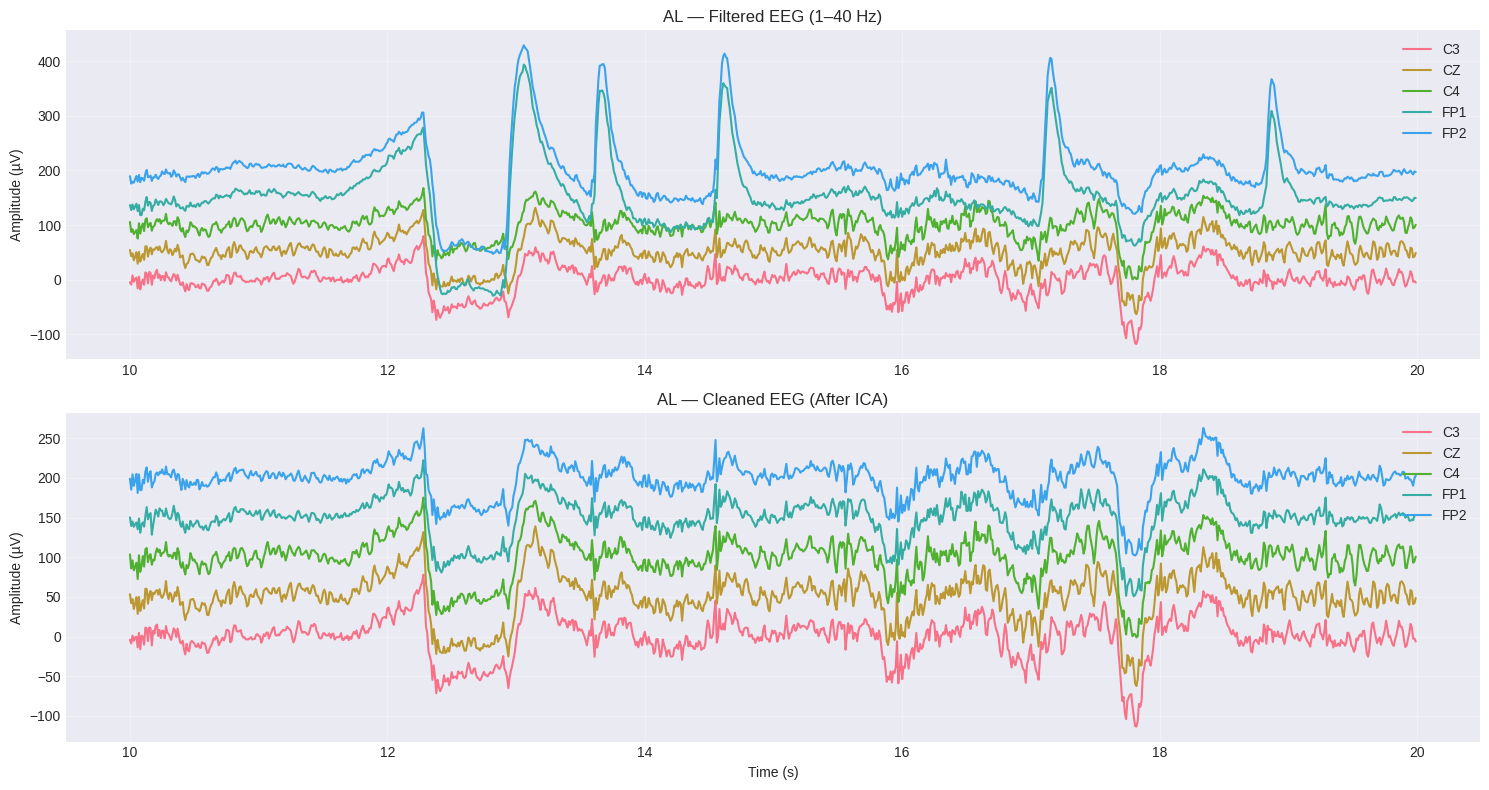

EEG visualization complete for subject al.


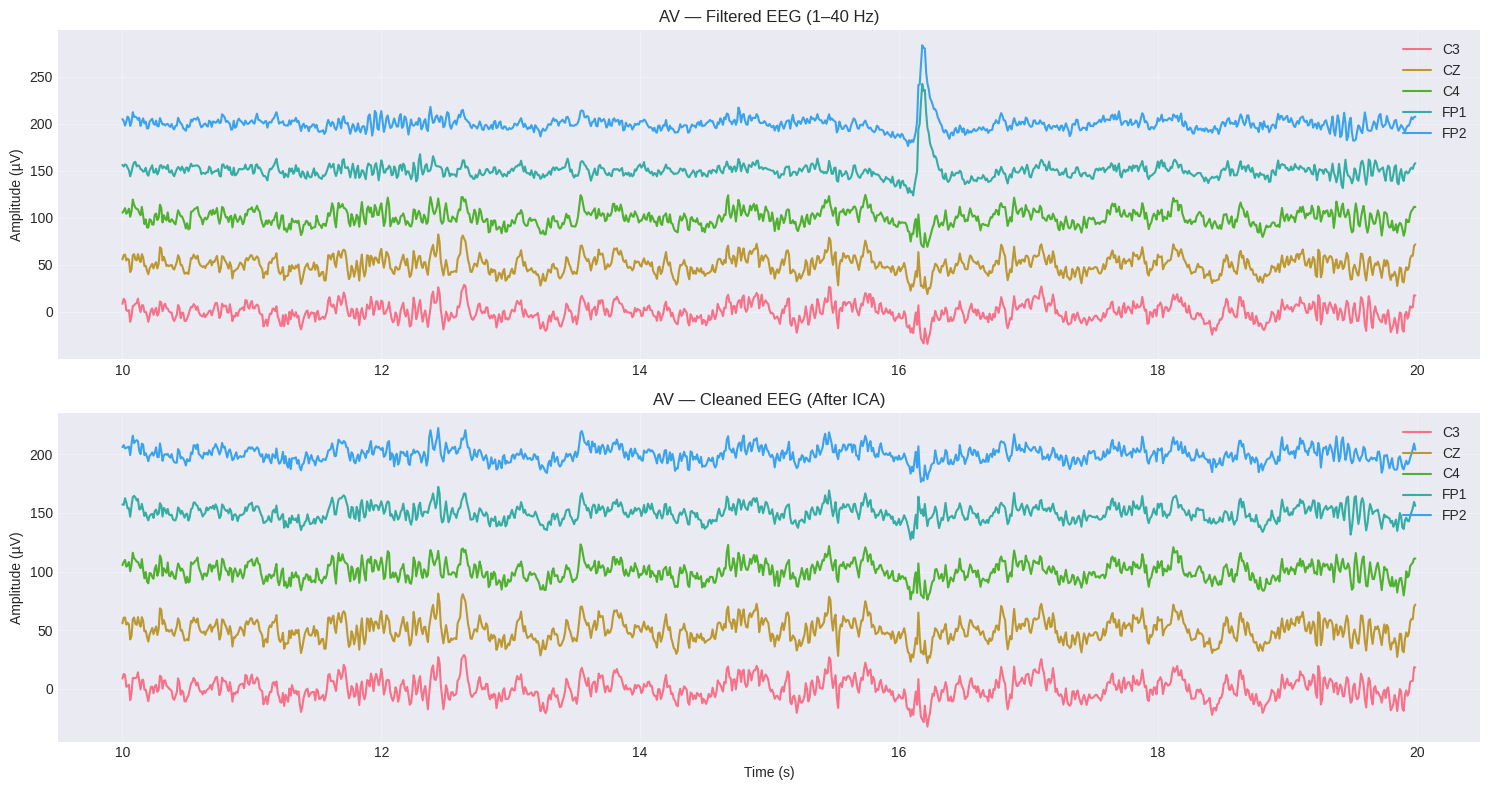

EEG visualization complete for subject av.


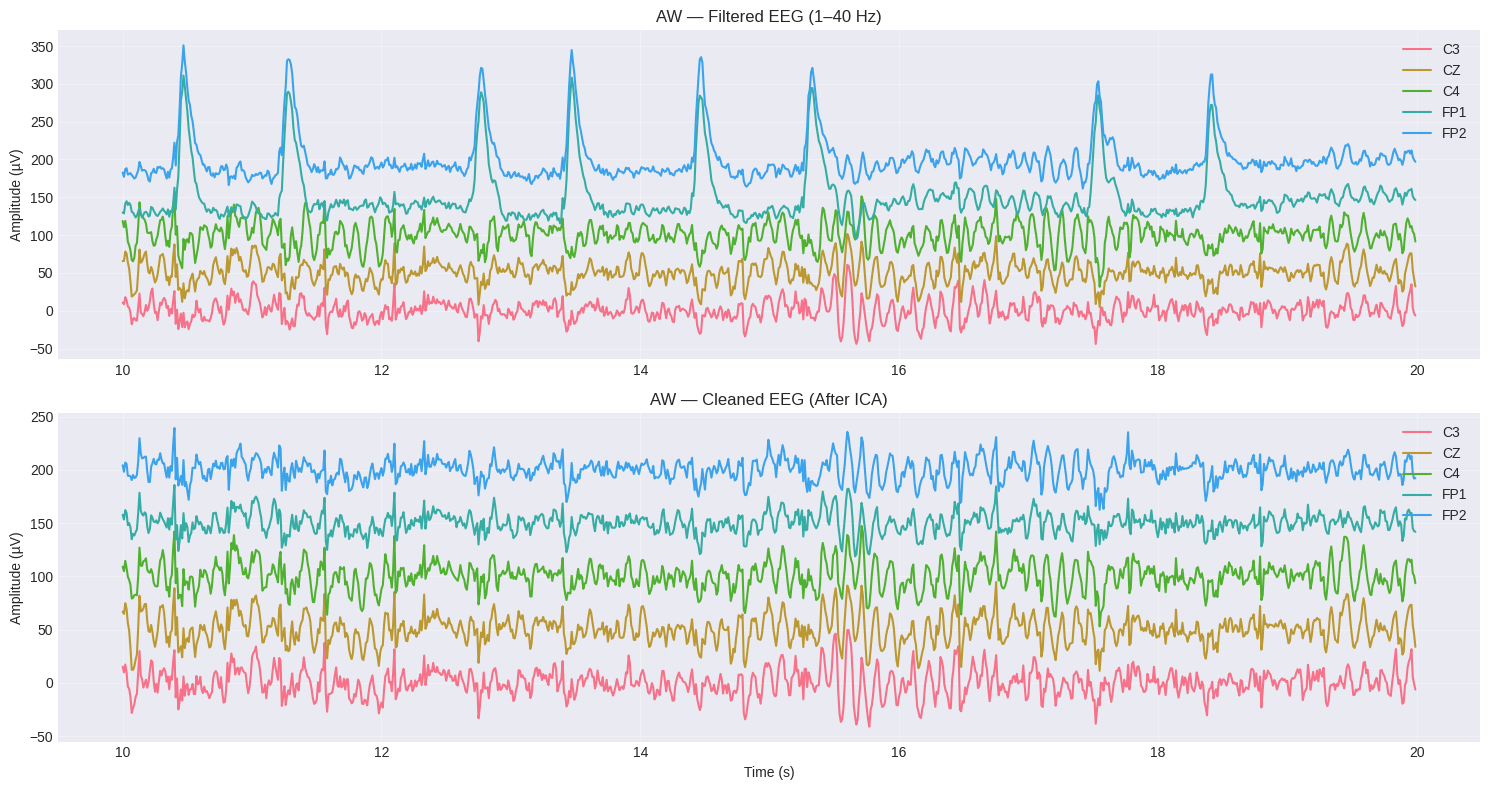

EEG visualization complete for subject aw.


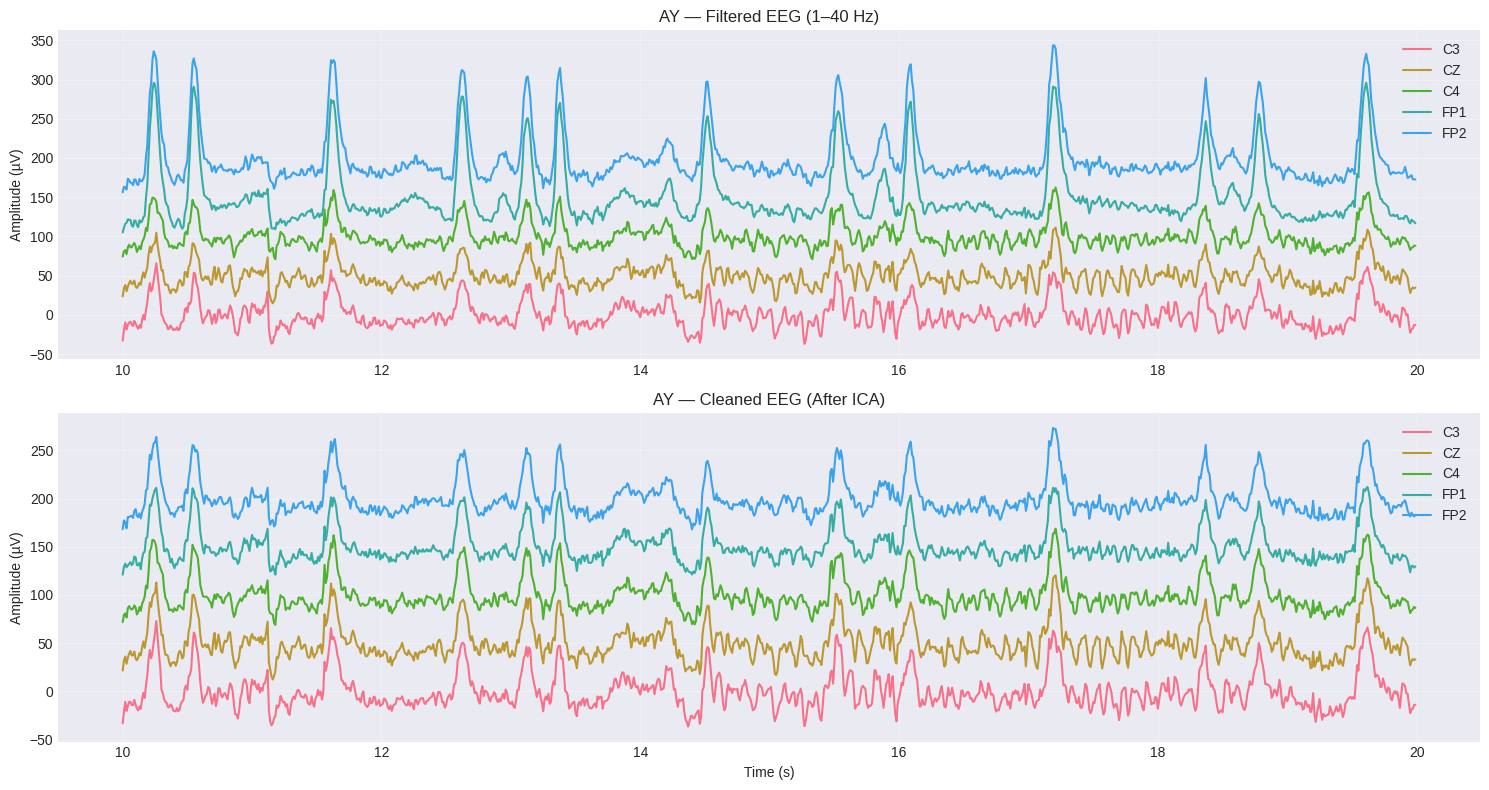

EEG visualization complete for subject ay.


In [55]:
channels_to_plot = ["C3", "CZ", "C4", "FP1", "FP2"]
start_time, duration = 10, 10

for s in SUBJECTS:
    raw_before = filtered_by_subject[s]
    raw_after  = raw_clean_by_subject[s]

    present = [ch for ch in channels_to_plot if ch in raw_before.ch_names]
    if not present:
        print(f"{s}: none of {channels_to_plot} present; skipping.")
        continue

    sfreq = raw_before.info["sfreq"]
    start_samp = int(start_time * sfreq)
    stop_samp  = int((start_time + duration) * sfreq)

    fig, axes = plt.subplots(2, 1, figsize=(15, 8))

    # Filtered (before ICA)
    data_raw, times = raw_before.get_data(picks=present, start=start_samp, stop=stop_samp, return_times=True)
    for i, ch in enumerate(present):
        axes[0].plot(times, data_raw[i] * 1e6 + i * 50, label=ch)
    axes[0].set_title(f"{s.upper()} — Filtered EEG (1–40 Hz)")
    axes[0].set_ylabel("Amplitude (µV)")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # Cleaned (after ICA)
    data_clean, times = raw_after.get_data(picks=present, start=start_samp, stop=stop_samp, return_times=True)
    for i, ch in enumerate(present):
        axes[1].plot(times, data_clean[i] * 1e6 + i * 50, label=ch)
    axes[1].set_title(f"{s.upper()} — Cleaned EEG (After ICA)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Amplitude (µV)")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"EEG visualization complete for subject {s}.")

### 4.4 Epoching

In [56]:
epochs_by_subject = {}

for s, raw_clean in raw_clean_by_subject.items():
    y = markers_by_subject[s]["y"]
    pos = markers_by_subject[s]["pos"]
    
    sel = ~np.isnan(y)
    ev = np.column_stack([pos[sel], np.zeros(np.sum(sel), dtype=int), y[sel].astype(int)])
    
    epochs = mne.Epochs(
        raw_clean,
        events=ev,
        event_id=EVENT_ID,
        tmin=EPOCH_TMIN,
        tmax=EPOCH_TMAX,
        baseline=None,
        preload=True,
        verbose=False,
        reject=dict(eeg=500e-6),
    )
    epochs_by_subject[s] = epochs
    
    n_right = len(epochs["right"])
    n_foot = len(epochs["foot"])
    print(f"{s}: right={n_right}, foot={n_foot}, total={len(epochs)}")

print("\nEpoching complete")

aa: right=80, foot=88, total=168
al: right=112, foot=112, total=224
av: right=42, foot=42, total=84
aw: right=30, foot=26, total=56
ay: right=17, foot=10, total=27

Epoching complete


### 4.4.1 Visualization: PSD Analysis

Effective window size : 4.010 (s)
Effective window size : 4.010 (s)


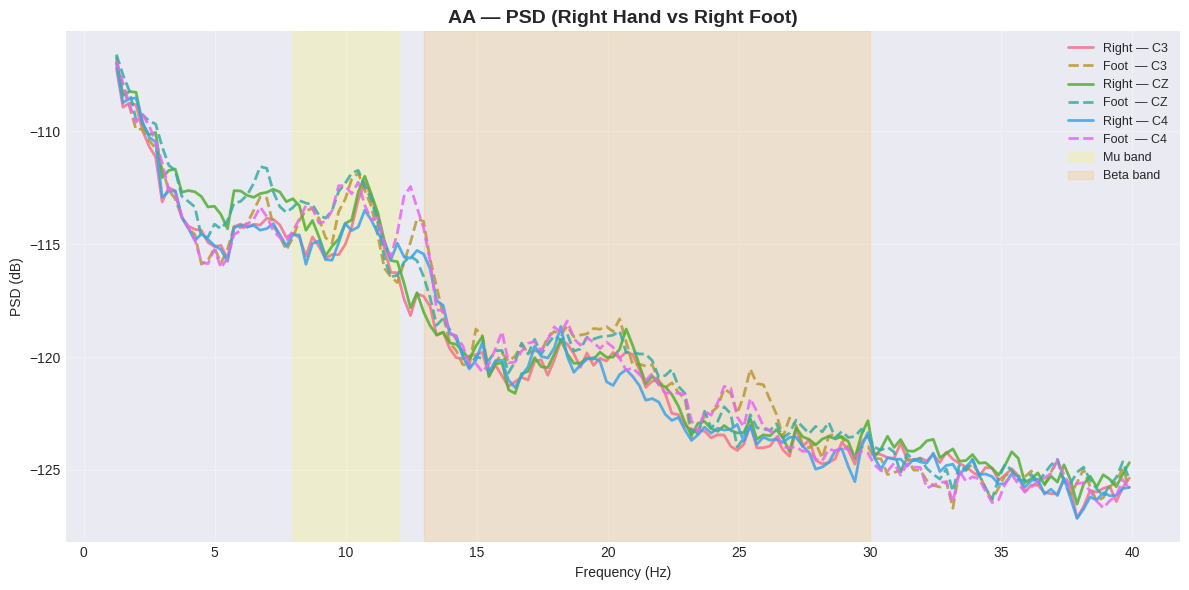

In [57]:
motor_channels = ["C3", "CZ", "C4"]
subj = "aa"

epochs = epochs_by_subject[subj]
available = [ch for ch in motor_channels if ch in epochs.ch_names]

psd_r = epochs["right"].compute_psd(method="welch", fmin=FILTER_LOW, fmax=FILTER_HIGH, picks=available)
R, freqs = psd_r.get_data(return_freqs=True)

psd_f = epochs["foot"].compute_psd(method="welch", fmin=FILTER_LOW, fmax=FILTER_HIGH, picks=available)
F, _ = psd_f.get_data(return_freqs=True)

R_mean = R.mean(axis=0)
F_mean = F.mean(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for i, ch in enumerate(available):
    ax.plot(freqs, 10*np.log10(R_mean[i]), label=f"Right — {ch}", alpha=0.85, linewidth=2)
    ax.plot(freqs, 10*np.log10(F_mean[i]), label=f"Foot  — {ch}", alpha=0.85, linestyle="--", linewidth=2)

ax.set_title(f"{subj.upper()} — PSD (Right Hand vs Right Foot)", fontweight="bold", fontsize=14)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (dB)")
ax.grid(True, alpha=0.3)
ax.axvspan(8, 12, alpha=0.15, color="yellow", label="Mu band")
ax.axvspan(13, 30, alpha=0.15, color="orange", label="Beta band")
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

### 4.4.2 Visualization: Evoked Responses

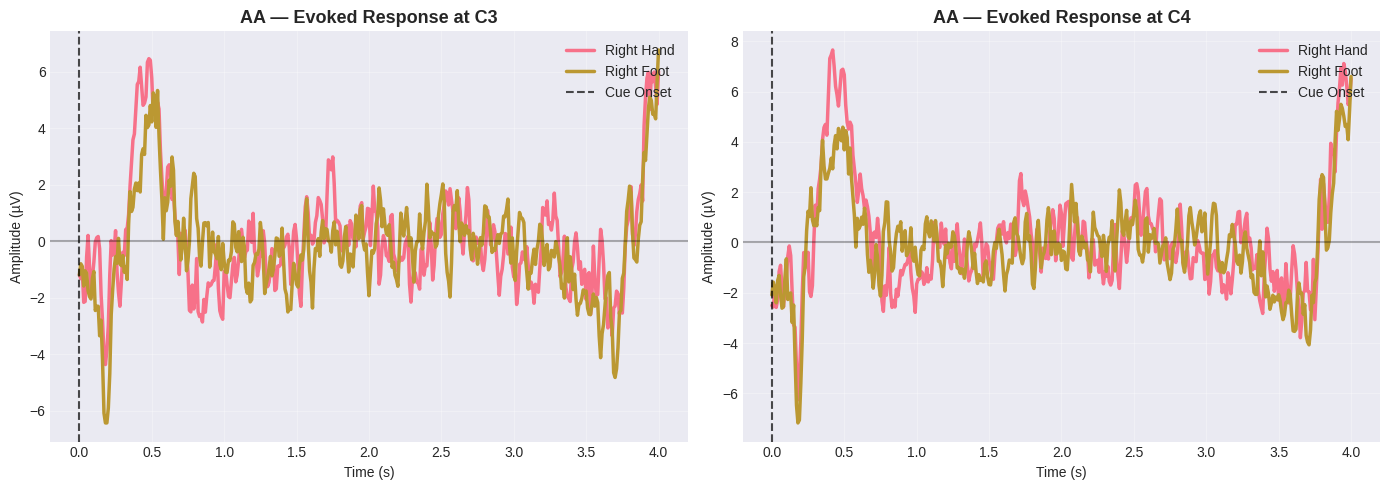

In [58]:
motor_channels = ["C3", "C4"]
subj = "aa"

epochs = epochs_by_subject[subj]
available = [ch for ch in motor_channels if ch in epochs.ch_names]

fig, axes = plt.subplots(1, len(available), figsize=(14, 5))
if len(available) == 1:
    axes = [axes]

for idx, ch in enumerate(available):
    ev_right = epochs["right"].average().pick([ch])
    ev_foot = epochs["foot"].average().pick([ch])

    t = ev_right.times
    axes[idx].plot(t, ev_right.data[0] * 1e6, label="Right Hand", lw=2.5)
    axes[idx].plot(t, ev_foot.data[0] * 1e6, label="Right Foot", lw=2.5)
    axes[idx].axvline(0, color="k", ls="--", label="Cue Onset", alpha=0.7)
    axes[idx].axhline(0, color="k", ls="-", alpha=0.3)
    axes[idx].set_title(f"{subj.upper()} — Evoked Response at {ch}", fontsize=13, fontweight="bold")
    axes[idx].set_xlabel("Time (s)")
    axes[idx].set_ylabel("Amplitude (µV)")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Prepare Data for Deep Learning

In [59]:
X_list, y_list = [], []

for s, epochs in epochs_by_subject.items():
    X_ep = epochs.get_data()
    y_ep = epochs.events[:, -1].astype(int)
    y_binary = (y_ep == 1).astype(int)
    
    X_list.append(X_ep)
    y_list.append(y_binary)

X_all = np.concatenate(X_list, axis=0)
y_all = np.concatenate(y_list, axis=0)

n_channels = X_all.shape[1]
n_timepoints = X_all.shape[2]

print(f"Combined data: {X_all.shape}")
print(f"Labels: {y_all.shape}")
print(f"Class distribution: 0={np.sum(y_all==0)}, 1={np.sum(y_all==1)}")
print(f"Channels={n_channels}, Timepoints={n_timepoints}, Sfreq={FS_EXPECTED}Hz")

Combined data: (559, 118, 401)
Labels: (559,)
Class distribution: 0=278, 1=281
Channels=118, Timepoints=401, Sfreq=100.0Hz


### 5.1 Train-Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

X_train_orig = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).long()
y_test_tensor = torch.from_numpy(y_test).long()

print(f"Training: {X_train_orig.shape}")
print(f"Test: {X_test_tensor.shape}")
print(f"Input shape for models: (batch, {n_channels}, {n_timepoints})")

Training: torch.Size([447, 118, 401])
Test: torch.Size([112, 118, 401])
Input shape for models: (batch, 118, 401)


## 6. Data Augmentation (Bonus)

In [61]:
class EEGAugmentation:
    @staticmethod
    def add_gaussian_noise(X, noise_level=0.05):
        noise = torch.randn_like(X) * noise_level
        return X + noise
    
    @staticmethod
    def channel_dropout(X, drop_prob=0.1):
        batch, ch, time = X.shape
        mask = torch.rand(batch, ch, 1) > drop_prob
        return X * mask.float()
    
    @staticmethod
    def time_shift(X, max_shift=10):
        batch, ch, time = X.shape
        shifted = torch.zeros_like(X)
        for i in range(batch):
            shift = np.random.randint(-max_shift, max_shift+1)
            if shift > 0:
                shifted[i, :, shift:] = X[i, :, :-shift]
            elif shift < 0:
                shifted[i, :, :shift] = X[i, :, -shift:]
            else:
                shifted[i] = X[i]
        return shifted
    
    @staticmethod
    def amplitude_scale(X, scale_range=(0.8, 1.2)):
        batch = X.shape[0]
        scales = torch.FloatTensor(batch, 1, 1).uniform_(*scale_range)
        return X * scales

def augment_data(X, y, augmentation_factor=2):
    X_aug_list, y_aug_list = [X], [y]
    
    for _ in range(augmentation_factor - 1):
        X_new = X.clone()
        
        if np.random.random() > 0.5:
            X_new = EEGAugmentation.add_gaussian_noise(X_new, noise_level=0.03)
        
        if np.random.random() > 0.5:
            X_new = EEGAugmentation.channel_dropout(X_new, drop_prob=0.1)
        
        if np.random.random() > 0.5:
            X_new = EEGAugmentation.time_shift(X_new, max_shift=8)
        
        if np.random.random() > 0.5:
            X_new = EEGAugmentation.amplitude_scale(X_new, scale_range=(0.9, 1.1))
        
        X_aug_list.append(X_new)
        y_aug_list.append(y)
    
    X_augmented = torch.cat(X_aug_list, dim=0)
    y_augmented = torch.cat(y_aug_list, dim=0)
    
    return X_augmented, y_augmented

print("Creating augmented dataset...")
X_train_aug, y_train_aug = augment_data(X_train_orig, y_train_tensor, augmentation_factor=2)

print(f"Original training: {X_train_orig.shape}")
print(f"Augmented training: {X_train_aug.shape}")
print(f"Augmentation increased data by {X_train_aug.shape[0] / X_train_orig.shape[0]:.1f}x")

Creating augmented dataset...
Original training: torch.Size([447, 118, 401])
Augmented training: torch.Size([894, 118, 401])
Augmentation increased data by 2.0x


### 6.1 Create DataLoaders

In [62]:
train_dataset_no_aug = TensorDataset(X_train_orig, y_train_tensor)
train_dataset_aug = TensorDataset(X_train_aug, y_train_aug)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train loader (no aug): {len(train_loader_no_aug)} batches")
print(f"Train loader (with aug): {len(train_loader_aug)} batches")
print(f"Test loader: {len(test_loader)} batches")

Train loader (no aug): 14 batches
Train loader (with aug): 28 batches
Test loader: 4 batches


## 7. Model Implementations

In [63]:
def create_models():
    models = {}
    
    models['EEGNet'] = EEGNetv4(
        n_chans=n_channels,
        n_outputs=2,
        n_times=n_timepoints,
    )
    
    models['ShallowFBCSPNet'] = ShallowFBCSPNet(
        n_chans=n_channels,
        n_outputs=2,
        n_times=n_timepoints,
    )
    
    models['Deep4Net'] = Deep4Net(
        n_chans=n_channels,
        n_outputs=2,
        n_times=n_timepoints,
    )
    
    try:
        models['EEGConformer'] = EEGConformer(
            n_chans=n_channels,
            n_outputs=2,
            n_times=n_timepoints,
        )
    except Exception as e:
        print(f"EEGConformer initialization failed: {e}")
        print("Skipping EEGConformer model")
    
    
    return models

models_dict = create_models()

for name, model in models_dict.items():
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {n_params:,} parameters")

EEGNet: 3,378 parameters
ShallowFBCSPNet: 191,602 parameters
Deep4Net: 317,827 parameters
EEGConformer: 533,506 parameters


## 8. Training Function

In [64]:
def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE, weight_decay=1e-4, model_name="Model"):
    print(f"\n{'='*60}")
    print(f"Training Configuration for {model_name}")
    print(f"{'='*60}")
    print(f"Learning Rate: {lr}")
    print(f"Weight Decay (L2): {weight_decay}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"Epochs: {epochs}")
    print(f"Optimizer: Adam")
    print(f"LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=15)")
    print(f"Loss Function: CrossEntropyLoss")
    
    dropout_info = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Dropout):
            dropout_info.append(f"  {name}: p={module.p}")
    if dropout_info:
        print(f"Dropout Layers:")
        for info in dropout_info[:3]:
            print(info)
        if len(dropout_info) > 3:
            print(f"  ... and {len(dropout_info)-3} more")
    print(f"{'='*60}\n")
    
    start_time = time.time()
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=50, verbose=False
    )
    
    history = {
        "train_losses": [],
        "train_accs": [],
        "test_losses": [],
        "test_accs": [],
        "best_acc": 0.0,
        "lr_history": [],
        "training_time": 0.0
    }
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == y_batch).sum().item()
        
        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        
        model.eval()
        test_loss, test_correct = 0.0, 0
        
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                test_loss += loss.item() * X_batch.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += (preds == y_batch).sum().item()
        
        test_loss /= len(test_loader.dataset)
        test_acc = test_correct / len(test_loader.dataset)
        
        history["train_losses"].append(train_loss)
        history["train_accs"].append(train_acc)
        history["test_losses"].append(test_loss)
        history["test_accs"].append(test_acc)
        history["lr_history"].append(optimizer.param_groups[0]['lr'])
        
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(test_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if test_acc > history["best_acc"]:
            history["best_acc"] = test_acc
        
        if (epoch + 1) % 20 == 0:
            lr_info = f", LR: {new_lr:.2e}" if old_lr != new_lr else ""
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_acc:.4f}, Test: {test_acc:.4f}, Best: {history['best_acc']:.4f}{lr_info}")
    
    end_time = time.time()
    training_time = end_time - start_time
    history["training_time"] = training_time
    
    print(f"\n{model_name} Training Complete")
    print(f"  Best Test Accuracy: {history['best_acc']:.4f}")
    print(f"  Training Time: {training_time:.2f}s ({training_time/60:.2f} min)")
    print(f"  Final Learning Rate: {optimizer.param_groups[0]['lr']:.2e}\n")
    
    return history

def get_predictions(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    return np.array(all_labels), np.array(all_preds)

## 9. Train All Models (No Augmentation)

In [65]:
print("="*60)
print("TRAINING WITHOUT DATA AUGMENTATION")
print("="*60 + "\n")

results_no_aug = {}
models_no_aug = {}

for name in models_dict.keys():
    print(f"Training {name} (no augmentation)...")
    model = create_models()[name]
    
    lr = 0.0005 if name == 'ShallowFBCSPNet' else LEARNING_RATE
    lr = 0.0005 if name == 'EEGConformer' else lr
    
    try:
        history = train_model(model, train_loader_no_aug, test_loader, epochs=EPOCHS, lr=lr, model_name=name)
        results_no_aug[name] = history
        models_no_aug[name] = model
    except Exception as e:
        print(f"ERROR: {name} training failed: {e}")
        print(f"Skipping {name}\\n")
        continue

print("\n" + "="*60)
print("NO AUGMENTATION RESULTS")
print("="*60)
for name, hist in results_no_aug.items():
    print(f"{name}: {hist['best_acc']:.4f}")

TRAINING WITHOUT DATA AUGMENTATION

Training EEGNet (no augmentation)...

Training Configuration for EEGNet
Learning Rate: 0.001
Weight Decay (L2): 0.0001
Batch Size: 32
Epochs: 400
Optimizer: Adam
LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=15)
Loss Function: CrossEntropyLoss
Dropout Layers:
  drop_1: p=0.25
  drop_2: p=0.25

Epoch 20/400 - Train: 0.7405, Test: 0.5000, Best: 0.5000
Epoch 40/400 - Train: 0.8277, Test: 0.5000, Best: 0.5000
Epoch 60/400 - Train: 0.8747, Test: 0.7500, Best: 0.7500
Epoch 80/400 - Train: 0.8859, Test: 0.7411, Best: 0.7946
Epoch 100/400 - Train: 0.8949, Test: 0.6696, Best: 0.7946
Epoch 120/400 - Train: 0.9060, Test: 0.7500, Best: 0.8214
Epoch 140/400 - Train: 0.9396, Test: 0.8125, Best: 0.8214
Epoch 160/400 - Train: 0.9105, Test: 0.8125, Best: 0.8304
Epoch 180/400 - Train: 0.9195, Test: 0.8214, Best: 0.8304
Epoch 200/400 - Train: 0.9262, Test: 0.8214, Best: 0.8304, LR: 3.91e-06
Epoch 220/400 - Train: 0.9262, Test: 0.8214, Best: 0.8304
Epoch 240/400

## 10. Train All Models (With Augmentation)

In [66]:
print("\n" + "="*60)
print("TRAINING WITH DATA AUGMENTATION")
print("="*60 + "\n")

results_aug = {}
models_aug = {}

for name in models_dict.keys():
    if name not in results_no_aug:
        print(f"Skipping {name} (failed in non-augmented training)\n")
        continue
    
    print(f"Training {name} (with augmentation)...")
    model = create_models()[name]
    
    lr = 0.0005 if name == 'ShallowFBCSPNet' else LEARNING_RATE
    lr = 0.0005 if name == 'EEGConformer' else lr
    
    try:
        history = train_model(model, train_loader_aug, test_loader, epochs=EPOCHS, lr=lr, model_name=name)
        results_aug[name] = history
        models_aug[name] = model
    except Exception as e:
        print(f"ERROR: {name} training failed: {e}")
        print(f"Skipping {name}\\n")
        continue

print("\n" + "="*60)
print("WITH AUGMENTATION RESULTS")
print("="*60)
for name, hist in results_aug.items():
    print(f"{name}: {hist['best_acc']:.4f}")


TRAINING WITH DATA AUGMENTATION

Training EEGNet (with augmentation)...

Training Configuration for EEGNet
Learning Rate: 0.001
Weight Decay (L2): 0.0001
Batch Size: 32
Epochs: 400
Optimizer: Adam
LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=15)
Loss Function: CrossEntropyLoss
Dropout Layers:
  drop_1: p=0.25
  drop_2: p=0.25

Epoch 20/400 - Train: 0.8579, Test: 0.5000, Best: 0.5000
Epoch 40/400 - Train: 0.9195, Test: 0.5089, Best: 0.7768
Epoch 60/400 - Train: 0.9530, Test: 0.5089, Best: 0.7857
Epoch 80/400 - Train: 0.9620, Test: 0.7768, Best: 0.8036, LR: 6.25e-05
Epoch 100/400 - Train: 0.9642, Test: 0.8036, Best: 0.8214
Epoch 120/400 - Train: 0.9541, Test: 0.8036, Best: 0.8214
Epoch 140/400 - Train: 0.9732, Test: 0.7946, Best: 0.8214
Epoch 160/400 - Train: 0.9676, Test: 0.7946, Best: 0.8214, LR: 1.95e-06
Epoch 180/400 - Train: 0.9609, Test: 0.7857, Best: 0.8214
Epoch 200/400 - Train: 0.9698, Test: 0.7857, Best: 0.8214
Epoch 220/400 - Train: 0.9676, Test: 0.7857, Best: 0.8214

## 11. Comparison: Augmentation Impact


AUGMENTATION IMPACT ANALYSIS
          Model  No Augmentation  With Augmentation  Improvement  Improvement %
         EEGNet         0.830357           0.821429    -0.008929      -1.075269
ShallowFBCSPNet         0.580357           0.616071     0.035714       6.153846
       Deep4Net         0.758929           0.875000     0.116071      15.294118
   EEGConformer         0.508929           0.767857     0.258929      50.877193



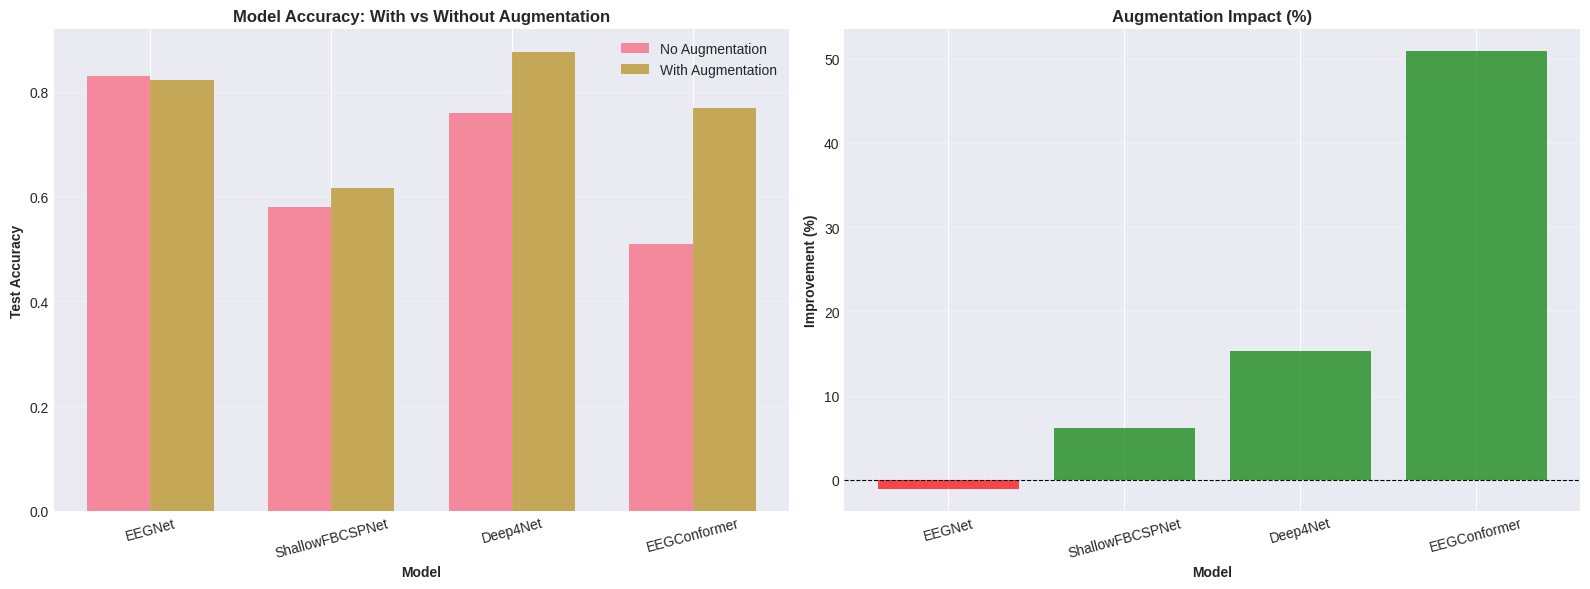

In [67]:
comparison_df = pd.DataFrame({
    'Model': list(results_no_aug.keys()),
    'No Augmentation': [results_no_aug[m]['best_acc'] for m in results_no_aug.keys()],
    'With Augmentation': [results_aug[m]['best_acc'] for m in results_aug.keys()]
})

comparison_df['Improvement'] = comparison_df['With Augmentation'] - comparison_df['No Augmentation']
comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['No Augmentation']) * 100

print("\n" + "="*80)
print("AUGMENTATION IMPACT ANALYSIS")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['No Augmentation'], width, label='No Augmentation', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['With Augmentation'], width, label='With Augmentation', alpha=0.8)
axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Test Accuracy', fontweight='bold')
axes[0].set_title('Model Accuracy: With vs Without Augmentation', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

colors = ['green' if i > 0 else 'red' for i in comparison_df['Improvement']]
axes[1].bar(x, comparison_df['Improvement %'], color=colors, alpha=0.7)
axes[1].set_xlabel('Model', fontweight='bold')
axes[1].set_ylabel('Improvement (%)', fontweight='bold')
axes[1].set_title('Augmentation Impact (%)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=15)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 12. Training Time


TRAINING TIME COMPARISON

Model                No Aug (min)    With Aug (min)  Increase
----------------------------------------------------------------------
EEGNet               4.18            8.12            1.95x
ShallowFBCSPNet      0.72            1.33            1.83x
Deep4Net             0.70            1.28            1.83x
EEGConformer         3.23            6.29            1.95x



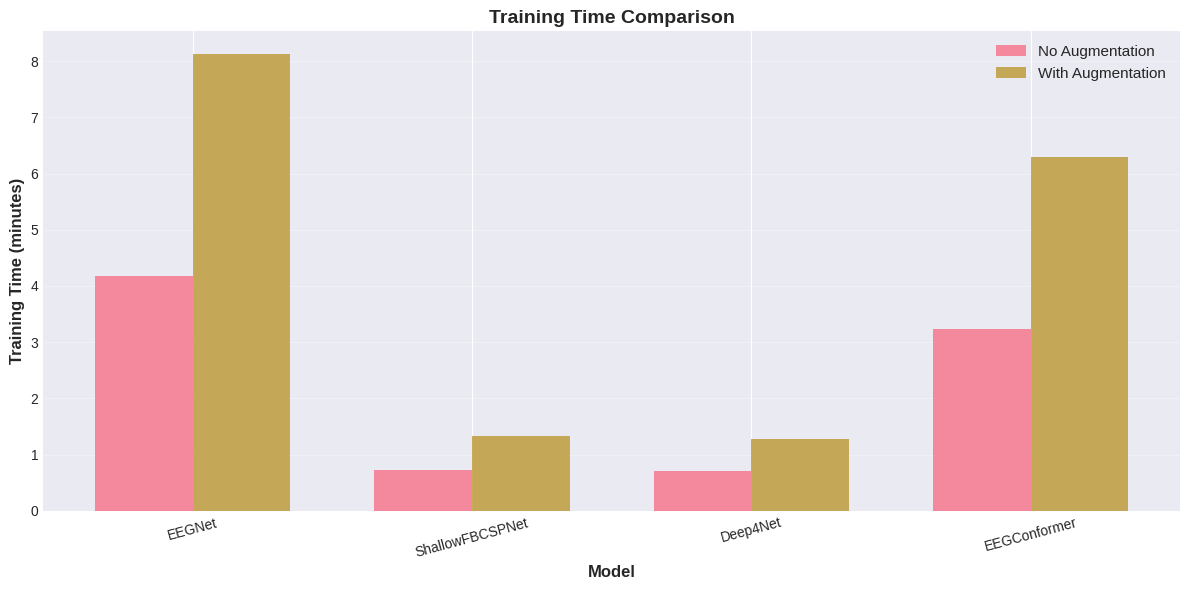

In [68]:
timing_df = pd.DataFrame({
    'Model': list(results_no_aug.keys()),
    'No Aug Time (s)': [results_no_aug[m]['training_time'] for m in results_no_aug.keys()],
    'With Aug Time (s)': [results_aug[m]['training_time'] for m in results_aug.keys()],
})

timing_df['No Aug Time (min)'] = timing_df['No Aug Time (s)'] / 60
timing_df['With Aug Time (min)'] = timing_df['With Aug Time (s)'] / 60
timing_df['Time Increase'] = timing_df['With Aug Time (s)'] / timing_df['No Aug Time (s)']

print("\n" + "="*80)
print("TRAINING TIME COMPARISON")
print("="*80)
print(f"\n{'Model':<20} {'No Aug (min)':<15} {'With Aug (min)':<15} {'Increase'}")
print("-"*70)
for idx, row in timing_df.iterrows():
    print(f"{row['Model']:<20} {row['No Aug Time (min)']:<15.2f} {row['With Aug Time (min)']:<15.2f} {row['Time Increase']:.2f}x")

print("\n" + "="*80)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x = np.arange(len(timing_df))
width = 0.35

ax.bar(x - width/2, timing_df['No Aug Time (min)'], width, label='No Augmentation', alpha=0.8)
ax.bar(x + width/2, timing_df['With Aug Time (min)'], width, label='With Augmentation', alpha=0.8)

ax.set_xlabel('Model', fontweight='bold', fontsize=12)
ax.set_ylabel('Training Time (minutes)', fontweight='bold', fontsize=12)
ax.set_title('Training Time Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(timing_df['Model'], rotation=15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 13. Training Curves Comparison

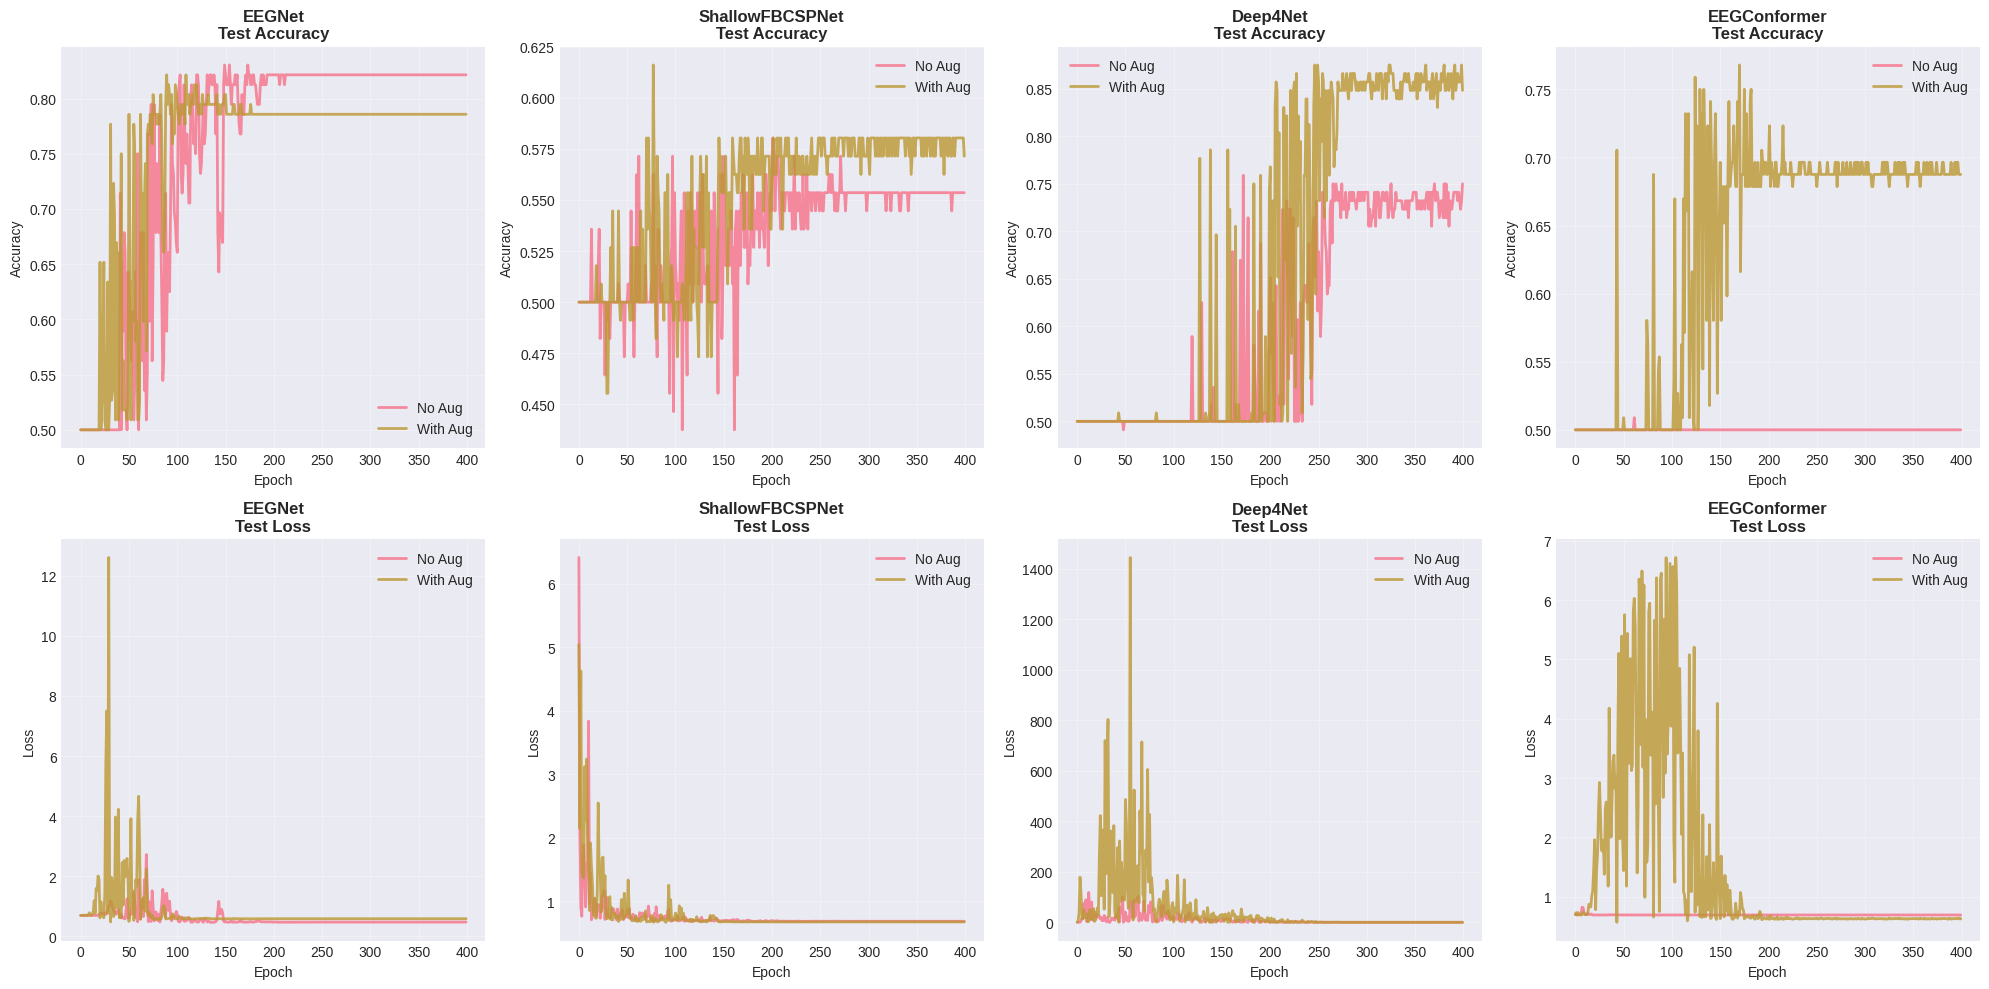

In [69]:
n_models = len(results_no_aug)
fig, axes = plt.subplots(2, n_models, figsize=(5*n_models, 10))

for idx, name in enumerate(results_no_aug.keys()):
    axes[0, idx].plot(results_no_aug[name]['test_accs'], label='No Aug', alpha=0.8, linewidth=2)
    axes[0, idx].plot(results_aug[name]['test_accs'], label='With Aug', alpha=0.8, linewidth=2)
    axes[0, idx].set_title(f"{name}\nTest Accuracy", fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    axes[1, idx].plot(results_no_aug[name]['test_losses'], label='No Aug', alpha=0.8, linewidth=2)
    axes[1, idx].plot(results_aug[name]['test_losses'], label='With Aug', alpha=0.8, linewidth=2)
    axes[1, idx].set_title(f"{name}\nTest Loss", fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Final Summary

In [70]:
print("\n" + "="*80)
print("FINAL PROJECT SUMMARY")
print("="*80)
print(f"\nDataset: BCI Competition III Dataset IVa")
print(f"Total samples: {X_all.shape[0]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"\nModels Implemented: {len(models_dict)}")
print(f"Models: {', '.join(models_dict.keys())}")
print(f"\nData Augmentation: Gaussian Noise, Channel Dropout, Time Shift, Amplitude Scale")
print(f"Augmentation Factor: 2x (from {X_train_orig.shape[0]} to {X_train_aug.shape[0]} samples)")

print(f"\n{'Model':<20} {'No Aug':<12} {'With Aug':<12} {'Improvement'}")
print("-"*60)
for name in results_no_aug.keys():
    no_aug_acc = results_no_aug[name]['best_acc']
    aug_acc = results_aug[name]['best_acc']
    improvement = (aug_acc - no_aug_acc) * 100
    print(f"{name:<20} {no_aug_acc:<12.4f} {aug_acc:<12.4f} {improvement:+.2f}%")


FINAL PROJECT SUMMARY

Dataset: BCI Competition III Dataset IVa
Total samples: 559
Training samples: 447
Test samples: 112

Models Implemented: 4
Models: EEGNet, ShallowFBCSPNet, Deep4Net, EEGConformer

Data Augmentation: Gaussian Noise, Channel Dropout, Time Shift, Amplitude Scale
Augmentation Factor: 2x (from 447 to 894 samples)

Model                No Aug       With Aug     Improvement
------------------------------------------------------------
EEGNet               0.8304       0.8214       -0.89%
ShallowFBCSPNet      0.5804       0.6161       +3.57%
Deep4Net             0.7589       0.8750       +11.61%
EEGConformer         0.5089       0.7679       +25.89%
